Let $x(t)$ be the population size governed by the DE

$$
\dot x = r_0x(1-(x/k)) - \frac{B x^2}{A+x^2}
$$

Suppose we only know the logistic term, and we want to approximate the other term with an universal approximator (such as an NN). So we have the UDE

$$
\dot x = r_0x(1-(x/k)) - \texttt{NN}_\theta(x, t)
$$

Our goal is to demonstrate our method of fitting the NN to the training data (which will be generated with a simulation of $x(t)$). In particular, we have the loss

$$
\mathcal L(\theta) := \sum_n (x_\theta(t_n)-\hat x_n)^2
$$

Whose gradient is calculated as

$$
\nabla_\theta \mathcal L = 2 \sum_n (x_\theta(t_n)-\hat x_n) \cdot \frac{\partial x_\theta}{\partial \theta}
$$

Moreover we will numerically simulate $x(t)$ with Newton's algorithm, which is given as

$$
x(t_{k+1}) = x(t_k) + h\mathcal F(\texttt{NN}_\theta, x, t)
$$

We will calculate the derivatives with *automatic differentiation*, provided by PyTorch.

In [2]:
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from torch import nn
import torch


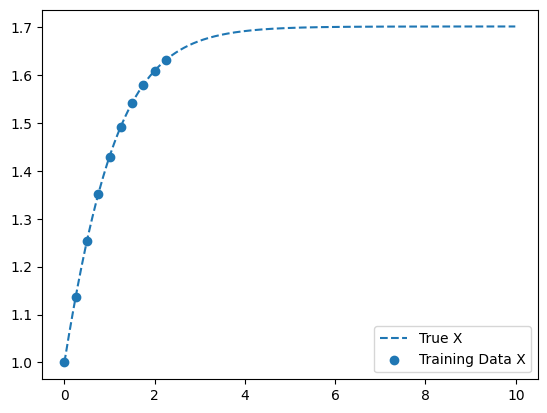

In [3]:
# Part 1: Synthetic Data Generation
r0 = 2
K = 3
A = 3
B = 3

def budworm(t, data, r0, K, A, B):
    x = data[0]
    return np.array([r0*x*(1-(x/K)) - (A* (x**2))/(B+(x**2))])

sol = solve_ivp(budworm, t_span = [0, 10], args= (r0, K, A, B), y0 = [1], rtol=1e-9, atol=1e-9, t_eval=np.arange(0, 10, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")

T_train = T[:250:25]
X_train = X[:250:25]

plt.scatter(T_train, X_train, label="Training Data X")

plt.legend()

plt.show()




In [ ]:
# define universal budworm model

class universal_budworm(nn.Module):
    def __init__(self, x0, r0, K):
        super().__init__()
        self.r0 = r0
        self.K = K
        self.x0 = x0

        self.net = nn.Sequential(
            nn.Linear(1, 3),
            nn.Tanh(),
            nn.Linear(3,3),
            nn.Tanh(),
            nn.Linear(3, 1)
        )       

    def forward(self, x, t):
        # returns dx/dt
        return self.r0*x*(1-x/self.K) - self.net(x)

In [5]:
my_budworm = universal_budworm(
    x0=1,
    r0=2,
    K=3
)

In [ ]:
def euler_solver(x0, model, t_eval):
    "Euler method for arbitrary mesh points, uses pytorch to maintain gradients"

    x_list = [x0.clone()]
    x_curr = x0.clone()
    
    for i in range(1, len(t_eval)):
        # Time step
        dt = float(t_eval[i] - t_eval[i-1])
        
        # Calculate dx/dt from the model
        dxdt = model(x_curr.view(1), torch.tensor(float(t_eval[i-1])))
        
        # Calculate next point
        x_next = x_curr + dt * dxdt.squeeze()
        x_list.append(x_next)
        
        x_curr = x_next
    
    return torch.stack(x_list)


In [7]:
x_euler = euler_solver(torch.tensor([1.]), my_budworm, t_euler := np.arange(0, 10, 0.001))

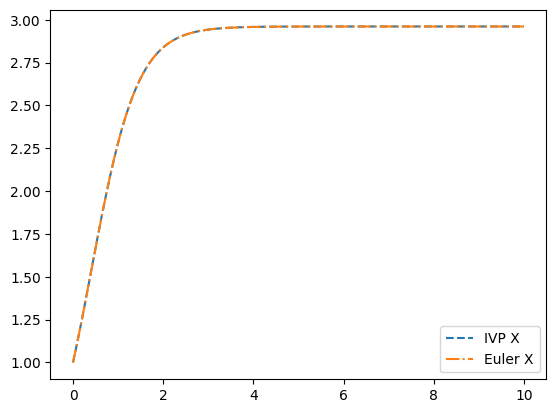

In [8]:
def ivp_universal_budworm(t, data, r0, K):
    x = data[0]
    return np.array([r0*x*(1-(x/K)) - my_budworm.net(torch.tensor(data, dtype=torch.float32)).detach().numpy()])

sol = solve_ivp(ivp_universal_budworm, t_span = [0, 10], args= (r0, K), y0 = [1], rtol=1e-9, atol=1e-9, dense_output=True)
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="IVP X")
plt.plot(t_euler,x_euler.detach().numpy(), "-.", label="Euler X")

plt.legend()

plt.show()

In [46]:
my_budworm = universal_budworm(
    x0=1,
    r0=2,
    K=3
)

In [47]:
#setup some stuff for animation
draw_x_euler = euler_solver(torch.tensor([1.]), my_budworm, draw_t_euler := np.arange(0, 10, 0.001))

with torch.no_grad():
    loss_0 = torch.tensor(0.0)
    for i, (t, x_true) in enumerate(zip(T_train, X_train)):
        loss_0 = loss_0 + (draw_x_euler[i] - x_true) ** 2
    
    loss_0 = loss_0 / len(T_train)

losses = loss_0
functions = draw_x_euler


In [48]:
from tqdm import tqdm 

lr = 0.01
optimizer = torch.optim.Adam(my_budworm.parameters(), lr=lr)

n_epochs = 1000
SKIP = 4

rtol = 1e-7

for EPOCH in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = euler_solver(torch.tensor(1.0, requires_grad=True), my_budworm, torch.tensor(T_train))
    
    # Compute loss at training points
    loss = torch.tensor(0.0)
    for i, (t, x_true) in enumerate(zip(T_train, X_train)):
        loss = loss + (x_pred[i] - x_true) ** 2
    
    loss = loss / len(T_train)
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        x_check = euler_solver(torch.tensor(1.0), my_budworm, torch.tensor(T_train))
        loss_check = torch.tensor(0.0)
        for i, (t, x_true) in enumerate(zip(T_train, X_train)):
            loss_check = loss_check + (x_check[i] - x_true) ** 2

        loss_check = loss_check / len(T_train)
        # print(f"Epoch {EPOCH}: MSE Loss = {loss_check.item()}")



    if EPOCH % SKIP == 0 and loss_check.item() >= rtol:
        with torch.no_grad():
            # print(EPOCH, "| This frame will be animated")

            # calculate forward solution with euler
            draw_x_euler = euler_solver(torch.tensor([1.]), my_budworm, draw_t_euler := np.arange(0, 10, 0.001))

            functions = torch.cat((functions, draw_x_euler), 1)
            losses = torch.cat((losses, torch.tensor([loss_check])))

100%|██████████| 1000/1000 [04:21<00:00,  3.83it/s]


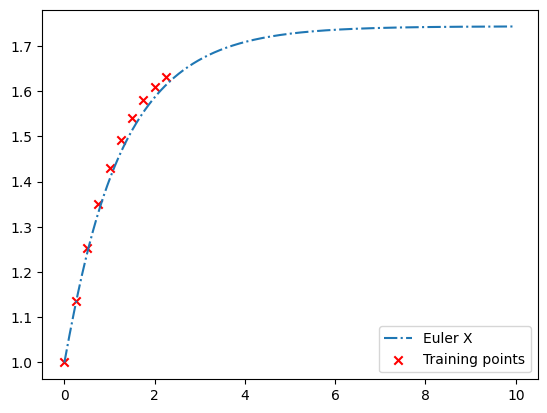

In [55]:
x_euler = euler_solver(torch.tensor([1.]), my_budworm, t_euler := torch.arange(0, 10, 0.01))                       

plt.plot(t_euler,x_euler.detach().numpy(), "-.", label="Euler X")
plt.scatter(T_train, X_train, marker="x", color='r', label="Training points")

plt.legend()

plt.show()

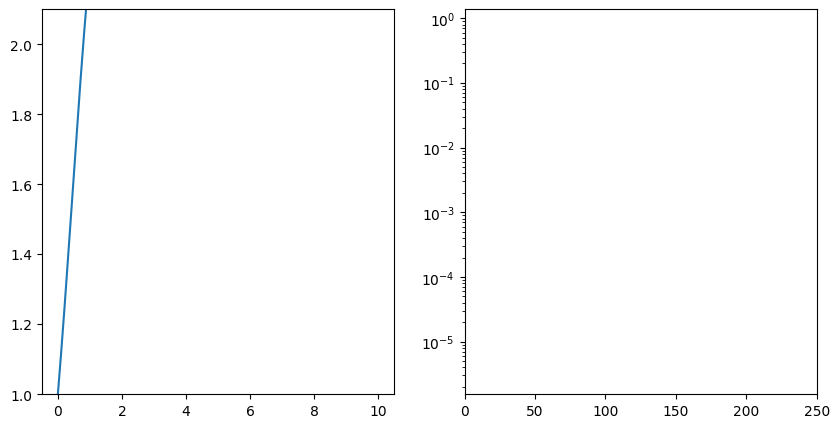

In [50]:
# set up canvas
from matplotlib import animation

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax_fun = axes[0]

ax_fun.set_ylim(1, 2.1)

ax_loss = axes[1]

fun_draw, = ax_fun.plot(draw_t_euler, functions[:, -1].detach().numpy())
fun_draw.set_data(draw_t_euler, functions[:, 0].detach().numpy())

loss_draw, = ax_loss.semilogy(range(0, 1000//SKIP+1), losses[:].detach().numpy(), "*")
loss_draw.set_data(range(0, 1), losses[:1].detach().numpy())

ax_loss.set_xlim(0, 1000//SKIP)

def animate(j):
    fun_draw.set_data(draw_t_euler, functions[:, j].detach().numpy())
    loss_draw.set_data(range(0,j), losses[:j])

    return fig 

ani = animation.FuncAnimation(fig, animate, frames=1000//SKIP)
ffmpeg_writer = animation.FFMpegWriter(fps=15)
ani.save(f'./test.mp4', writer=ffmpeg_writer)

In [51]:
def agnesi(A, B, x):
    return (A * (x**2))/(B+(x**2))

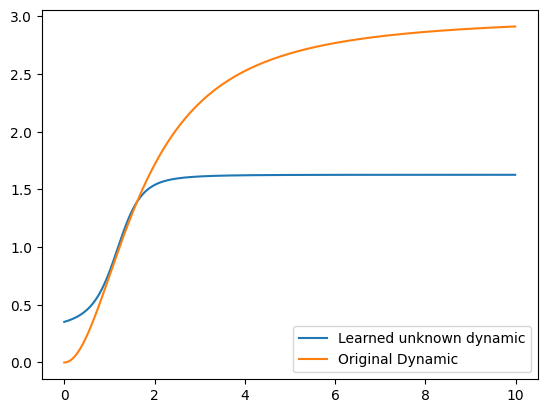

In [52]:
y = torch.zeros(torch.arange(0,10,0.01).shape)
y_target = torch.zeros(torch.arange(0,10,0.01).shape)

for i, x in enumerate(torch.arange(0, 10, 0.01)):
    y[i] = my_budworm.net(torch.tensor([x]))
    y_target[i] = agnesi(3, 3, x)

y_np = y.detach().numpy()
y_np_agnesi = y_target.detach().numpy()

plt.plot(np.arange(0,10,0.01), y_np, label="Learned unknown dynamic")
plt.plot(np.arange(0,10,0.01), y_np_agnesi, label="Original Dynamic")

plt.legend()

plt.show()

In [56]:
# weird

In [ ]:
# something i should've tried before: fitting the Agnesi function in [0,10]

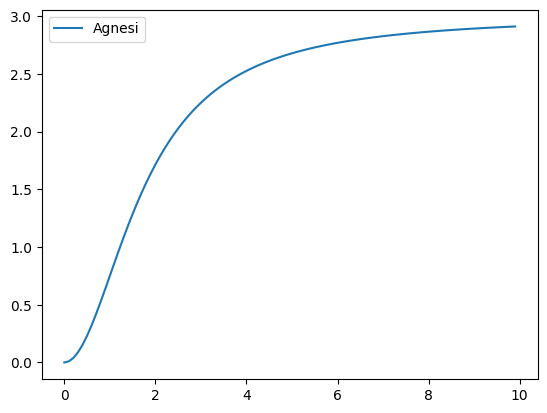

In [671]:
y_train = torch.zeros(torch.arange(0,10,0.1).shape)

for i, x in enumerate(x_train := torch.arange(0, 10, 0.1)):
    y_train[i] = agnesi(3, 3, x)

y_train_np = y_train.detach().numpy()

plt.plot(np.arange(0,10,0.1), y_train_np, label="Agnesi")

plt.legend()

plt.show()

In [686]:
dataset = torch.stack((x_train, y_train))


In [701]:
my_nn = nn.Sequential(
    nn.Linear(1, 3),
    nn.Tanh(),
    nn.Linear(3,3),
    nn.Tanh(),
    nn.Linear(3, 1)
)

lr = 0.01
optimizer = torch.optim.Adam(my_nn.parameters(), lr)

for EPOCH in range(1, 1000):
    my_nn.zero_grad()

    # calculate loss

    loss = torch.tensor([.0])

    for x, y in zip(x_train, y_train):
        loss += (my_nn(torch.tensor([x]))-torch.tensor([y]))**2
    
    loss /= x_train.shape[0]

    loss.backward()

    optimizer.step()

    print(f"EPOCH {EPOCH}, LOSS: {loss}")



EPOCH 1, LOSS: tensor([2.7003], grad_fn=<DivBackward0>)
EPOCH 2, LOSS: tensor([2.5613], grad_fn=<DivBackward0>)
EPOCH 3, LOSS: tensor([2.4252], grad_fn=<DivBackward0>)
EPOCH 4, LOSS: tensor([2.2930], grad_fn=<DivBackward0>)
EPOCH 5, LOSS: tensor([2.1659], grad_fn=<DivBackward0>)
EPOCH 6, LOSS: tensor([2.0445], grad_fn=<DivBackward0>)
EPOCH 7, LOSS: tensor([1.9293], grad_fn=<DivBackward0>)
EPOCH 8, LOSS: tensor([1.8207], grad_fn=<DivBackward0>)
EPOCH 9, LOSS: tensor([1.7185], grad_fn=<DivBackward0>)
EPOCH 10, LOSS: tensor([1.6227], grad_fn=<DivBackward0>)
EPOCH 11, LOSS: tensor([1.5328], grad_fn=<DivBackward0>)
EPOCH 12, LOSS: tensor([1.4485], grad_fn=<DivBackward0>)
EPOCH 13, LOSS: tensor([1.3693], grad_fn=<DivBackward0>)
EPOCH 14, LOSS: tensor([1.2948], grad_fn=<DivBackward0>)
EPOCH 15, LOSS: tensor([1.2249], grad_fn=<DivBackward0>)
EPOCH 16, LOSS: tensor([1.1593], grad_fn=<DivBackward0>)
EPOCH 17, LOSS: tensor([1.0979], grad_fn=<DivBackward0>)
EPOCH 18, LOSS: tensor([1.0407], grad_fn

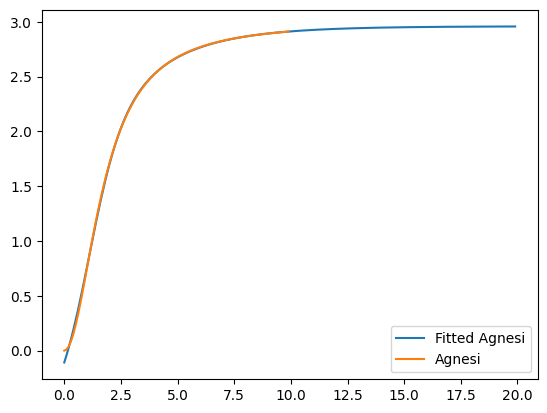

In [707]:
y_pred = torch.zeros(torch.arange(0,20,0.1).shape)

for i, x in enumerate(x_train := torch.arange(0, 20, 0.1)):
    y_pred[i] = my_nn(torch.tensor([x]))[0]

y_pred_np = y_pred.detach().numpy()

plt.plot(np.arange(0,20,0.1), y_pred_np, label="Fitted Agnesi")
plt.plot(np.arange(0,10,0.1), y_train_np, label="Agnesi")

plt.legend()

plt.show()